# MMN12

submitted by: ******

date: 2024-06-15


## Question 1 - implementing

```python
my_sampler(size, dist, requires_grad=False)
```


In [26]:
import torch

def dist_format_check(dist: any) -> torch.Tensor:
    """
    Ensure that `dist` is a 1D tensor of probabilities.
    Accepts: 1D torch.Tensor, list, or tuple.
    """
    if isinstance(dist, torch.Tensor):
        if dist.dim() != 1:
            raise ValueError("dist must be a 1D tensor of probabilities.")
        return dist.to(dtype=torch.float32)

    if isinstance(dist, (list, tuple)):
        dist_tensor = torch.tensor(dist, dtype=torch.float32)
        if dist_tensor.dim() != 1:
            raise ValueError("dist must be a 1D tensor of probabilities.")
        return dist_tensor

    raise TypeError("dist must be a 1D tensor or a list/tuple of probabilities.")


def dist_values_check(dist: torch.Tensor) -> bool:
    """
    Check that all probabilities are positive and sum to 1.
    """
    if torch.any(dist <= 0):
        raise ValueError("All probabilities must be positive.")

    sum_vals = dist.sum()
    one = torch.tensor(1.0, dtype=dist.dtype, device=dist.device)

    if not torch.isclose(sum_vals, one):
        raise ValueError(f"Distribution values must sum to 1 (got {sum_vals.item():.6f}).")

    return True


def test_dist(dist: any) -> torch.Tensor:
    """
    Format and validate the distribution.
    """
    dist_tensor = dist_format_check(dist)
    dist_values_check(dist_tensor)
    return dist_tensor


 Building the constractore

In [27]:
def my_sampler(size, dist, requires_grad: bool = False) -> torch.Tensor:
    """
    Sample from a discrete distribution defined by `dist`.
    - size: int or tuple, the desired output shape.
    - dist: 1D tensor/list/tuple of probabilities, dist[i] = P(I = i).
    - requires_grad: if True, return a tensor tracked by autograd,
      but the sampling computation itself is not tracked.
    """
    # Validate distribution
    dist_tensor = test_dist(dist)
    n = dist_tensor.numel()

    # Cumulative distribution
    cum_dist = torch.cumsum(dist_tensor, dim=0)  # shape: (n,)

    with torch.no_grad():
        # Uniform samples in [0, 1), same shape as the output
        U = torch.rand(size)

        # Initialize result with the last category (index n-1)
        res = torch.full_like(U, fill_value=float(n - 1))

        # Single allowed loop: i = 0, ..., n-2
        for i in range(n - 1):
            if i == 0:
                mask = U < cum_dist[0]
            else:
                mask = (U >= cum_dist[i - 1]) & (U < cum_dist[i])
            res[mask] = float(i)

    # Autograd should only track further operations, not the sampling itself
    if requires_grad:
        res.requires_grad_(True)

    return res

Plotting histograms:   0%|          | 0/4 [00:00<?, ?it/s]

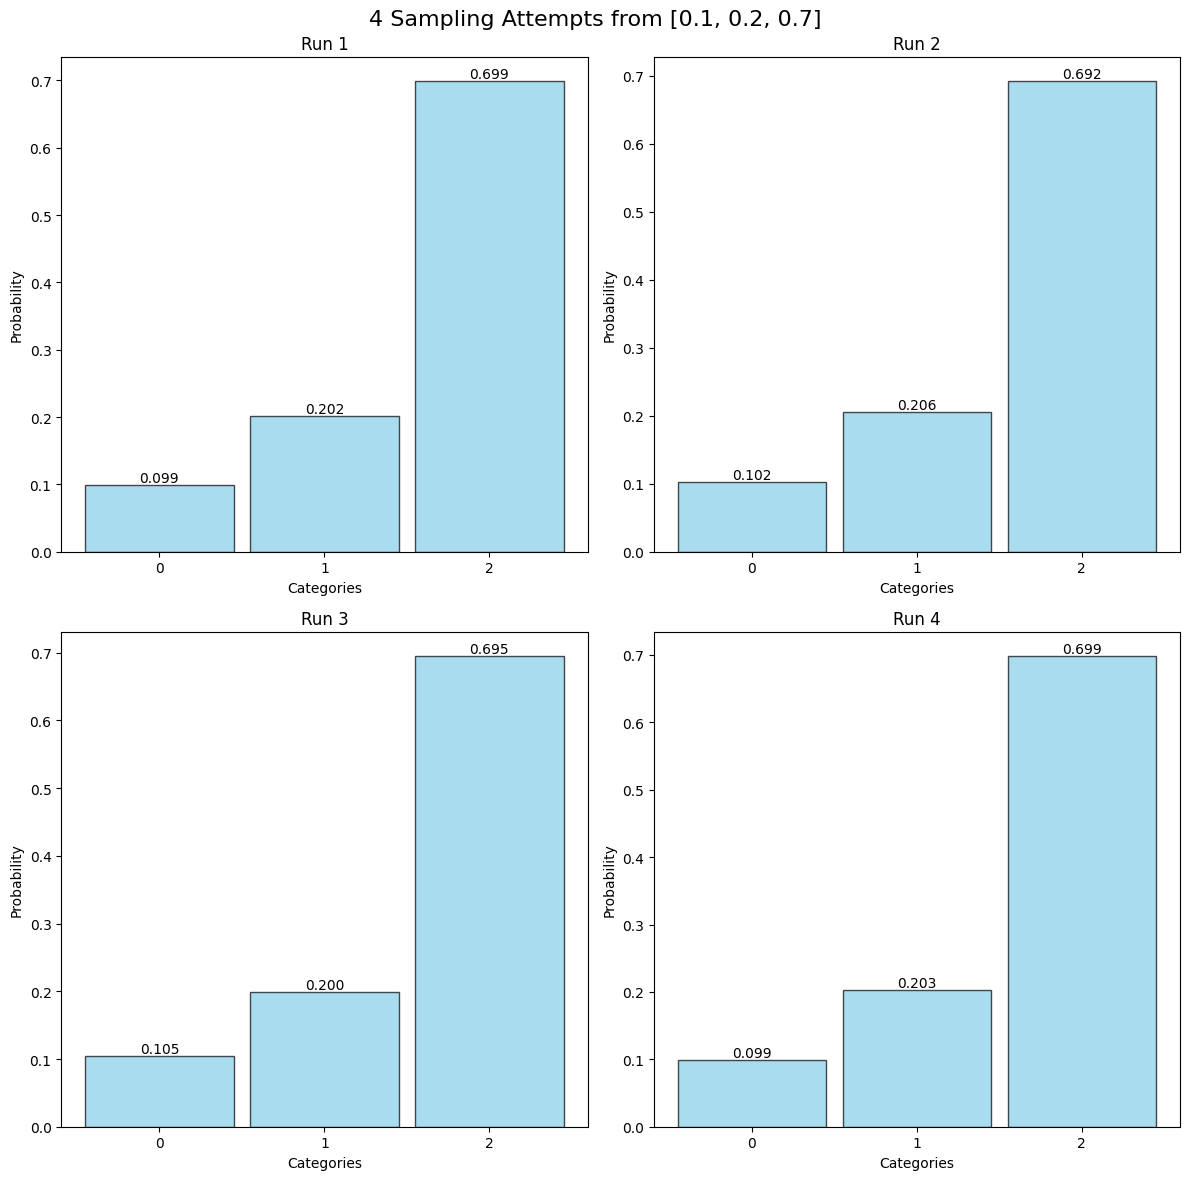

In [28]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Generate 4 independent sampling runs
arr = [my_sampler(10000, [0.1, 0.2, 0.7]) for _ in range(4)]

# Bin edges so each category has width exactly 1
bin_edges = [-0.5, 0.5, 1.5, 2.5]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for i, ax in enumerate(tqdm(axes.flat, desc="Plotting histograms")):
    data = arr[i].numpy()

    # Plot histogram with density=True and bin width 1 → heights = probabilities
    counts, _, patches = ax.hist(
        data,
        bins=bin_edges,
        density=True,
        alpha=0.7,
        rwidth=0.9,
        color='skyblue',
        edgecolor='black'
    )

    # Add labels on top of bars
    ax.bar_label(ax.containers[0], fmt='%.3f')

    ax.set_xticks([0, 1, 2])
    ax.set_xlabel("Categories")
    ax.set_ylabel("Probability")
    ax.set_title(f"Run {i+1}")

fig.suptitle("4 Sampling Attempts from [0.1, 0.2, 0.7]", fontsize=16)
plt.tight_layout()
plt.show()


### **Discussion & Conclusions**

---

#### **Explanation**

In this exercise, we sampled values from the discrete distribution **[0.1, 0.2, 0.7]**, where each probability corresponds to choosing categories **0**, **1**, and **2**, respectively.
We repeated the sampling procedure **four times**, drawing **10,000 samples** per run.

---

#### **What we did**

* Used the custom **`my_sampler`** function to generate 10,000 categorical samples per experiment.
* Displayed the four results in a **2×2 grid** to visually compare the stability and randomness across repeated runs.
* Used bin edges **[-0.5, 0.5, 1.5, 2.5]** so that each histogram bin covers exactly one category (width = 1).
  This makes the histogram bar heights equal to the **empirical probabilities**.

---

#### **Why the graph is built this way**

* The **2×2 grid** allows an easy side-by-side comparison of multiple independent runs.
* Setting bin width to **1** ensures that `density=True` makes the bar height equal the probability for each category, rather than a density scaled by bin width.
* This produces histograms where the bar heights should be close to **0.1**, **0.2**, and **0.7**, matching the target distribution.

---

#### **Why we see ~10%, ~20%, ~70% across four runs**

* Each of the four runs samples independently from the same distribution.
* With **10,000 samples**, the **law of large numbers** ensures that the observed frequencies converge to the true probabilities:

  * ~10% of samples fall in category **0**
  * ~20% fall in category **1**
  * ~70% fall in category **2**
* Although random variation exists, the large number of samples keeps the results consistently close to the expected proportions.


## Question 2 - implementing MyScalar


### Scalar representation and global gradient storage

In this cell I define the basic building blocks for my automatic differentiation system:

- `MyScalar` is a lightweight class that represents a single scalar value in the computation graph.  
  - `value` stores the numeric (float) value of the scalar.  
  - `parent` points to the `MyScalar` from which this value was computed (or `None` for a leaf variable).  
  - `grad_local` stores the *local derivative* \(\partial(\text{this})/\partial(\text{parent})\), evaluated at the current `value`.  
  Storing `grad_local` as a number (instead of a function) is sufficient here because all derivatives are scalar and evaluated immediately when the node is created.

- `GRAD_DICT` is a global dictionary that will be used by the `gradient_get` function to accumulate the final derivatives of the output with respect to each node in the graph.  
  The keys are `MyScalar` objects and the values are the corresponding gradients \( \frac{\partial \text{output}}{\partial \text{node}} \).

Finally, I initialize an empty `tests` list that will collect all test functions defined in later cells. These tests will be executed at the end to validate both the forward computations and the gradients against PyTorch’s autograd.


In [29]:
import math  # for exp, etc.

# global dict for gradients (key: MyScalar object, value: d(output)/d(that object))
GRAD_DICT = {}

class MyScalar:
    def __init__(self, value, parent=None, grad_local=1.0, name=None):
        self.value = float(value)
        self.parent = parent        # another MyScalar, or None for leaf
        self.grad_local = float(grad_local)  # local derivative: d(this)/d(parent)


    def __repr__(self):
        return f"MyScalar(value={self.value}, grad_local={self.grad_local})"

tests = [] # List to save all tests that will be defined per cell and run at the end

### Test helpers and first basic test

This cell defines small helper functions used throughout the test suite:

- `check` and `assert_close` let me perform assertions inside lambdas (since plain `assert` is not allowed there).
- `run` executes a test and prints `[OK]` or `[FAIL]`.

The final line registers `scalar_init_basic`, a simple test that checks:
1. `MyScalar` stores its numeric value correctly,  
2. leaf nodes have `parent=None`,  
3. the default `grad_local` is initialized to `1.0`.

These helpers allow all tests to be added as compact one-liner lambdas.


In [30]:
def check(cond, msg=""):
    """Use instead of assert inside lambdas."""
    if not cond:
        raise AssertionError(msg or "check() failed")

def assert_close(a, b, tol=1e-6):
    if abs(a - b) > tol:
        raise AssertionError(f"Expected {b}, got {a}")
    return True

def run(name, fn):
    try:
        fn()
        print(f"[OK]   {name}")
    except Exception as e:
        print(f"[FAIL] {name} - {type(e).__name__}: {e}")

# 1. Basic MyScalar
tests.append(("scalar_init_basic",
    lambda: (assert_close(MyScalar(2.5).value, 2.5),check(MyScalar(3.0).parent is None),assert_close(MyScalar(4.0).grad_local, 1.0))))


### `sin` operation and its test

This cell implements the `sin` operation for `MyScalar`.  
The function computes both the forward value `sin(x)` and the local derivative `cos(x)` using PyTorch for numerical accuracy, then stores them as floats in a new `MyScalar` node whose `parent` is the input.  
This ensures that the forward computation and the local derivative of `sin` match the PyTorch reference implementation.


In [31]:
def sin(x: MyScalar) -> MyScalar:
    """
    y = sin(x)
    parent = x
    grad_local = dy/dx = cos(x)
    """
    t = torch.tensor(x.value, dtype=torch.float32)

    value = torch.sin(t).item()      # float
    grad_local = torch.cos(t).item() # float

    return MyScalar(value=value, parent=x, grad_local=grad_local)

MyScalar.sin = sin # Adding sin as a method of MyScalar

# 2. Adding sin test to the tests list
tests.append(("sin_value_and_grad_local",
    lambda: (lambda x=0.7: (assert_close(sin(MyScalar(x)).value, torch.sin(torch.tensor(x)).item()),
            assert_close(sin(MyScalar(x)).grad_local, torch.cos(torch.tensor(x)).item())
        ))()))

### `cos` operation and its test

This cell defines the `cos` operation for `MyScalar`.  
It computes the forward value `cos(x)` and the local derivative `-sin(x)` using PyTorch, then returns a new `MyScalar` node whose `parent` is the input.  
A corresponding test verifies that both the computed value and the stored local derivative match PyTorch’s results, ensuring correctness of the `cos` implementation.


In [32]:
def cos(x: MyScalar) -> MyScalar:
    """
    y = cos(x)
    parent = x
    grad_local = dy/dx = -sin(x)
    """
    t = torch.tensor(x.value, dtype=torch.float32)

    value = torch.cos(t).item()
    grad_local = (-torch.sin(t)).item()

    return MyScalar(value=value, parent=x, grad_local=grad_local)

MyScalar.cos = cos # Adding cos as a method of MyScalar

# 3. Adding cos test to the tests list
tests.append(("cos_value_and_grad_local",
    lambda: (lambda x=1.2: (assert_close(cos(MyScalar(x)).value, torch.cos(torch.tensor(x)).item()),
            assert_close(cos(MyScalar(x)).grad_local, (-torch.sin(torch.tensor(x))).item())
        ))()))

### `ln` operation and its test

This cell implements the natural logarithm for `MyScalar`.  
The forward value `ln(x)` and its local derivative `1/x` are computed using PyTorch and stored as floats in a new `MyScalar` node whose `parent` is the input.  

The accompanying test checks that both the computed value and the local derivative match PyTorch’s `log` function, ensuring the correctness of the `ln` implementation.

In [33]:
def ln(x: MyScalar) -> MyScalar:
    t = torch.tensor(x.value, dtype=torch.float32)

    value = torch.log(t).item()
    grad_local = (1.0 / t).item()

    return MyScalar(value=value, parent=x, grad_local=grad_local)

MyScalar.ln = ln # Adding ln as a method of MyScalar

# 4. Adding ln test to the tests list
tests.append(("ln_value_and_grad_local",
    lambda: (lambda x=2.3: (assert_close(ln(MyScalar(x)).value, torch.log(torch.tensor(x)).item()),
            assert_close(ln(MyScalar(x)).grad_local, (1.0/torch.tensor(x)).item())
        ))()))

### `exp` operation and its test

This cell defines the exponential function for `MyScalar`.  
Both the forward value `exp(x)` and the local derivative (also `exp(x)`) are computed using PyTorch for numerical accuracy, then stored as floats in a new `MyScalar` node whose `parent` is the input.

The accompanying test verifies that the computed value and `grad_local` match PyTorch’s results, ensuring the correctness of the `exp` implementation.


In [34]:
def exp(x: MyScalar) -> MyScalar:
    t = torch.tensor(x.value, dtype=torch.float32)

    value_t = torch.exp(t)          # tensor
    value = value_t.item()          # float
    grad_local = value_t.item()     # derivative of e^x is e^x

    return MyScalar(value=value, parent=x, grad_local=grad_local)

MyScalar.exp = exp # Adding exp as a method of MyScalar

# 5. Adding exp test to the tests list
tests.append(("exp_value_and_grad_local",
        lambda: (lambda x=0.9: (assert_close(exp(MyScalar(x)).value, torch.exp(torch.tensor(x)).item()),
            assert_close(exp(MyScalar(x)).grad_local, torch.exp(torch.tensor(x)).item())
        ))()))

### `power` operation and its test

This cell implements the power function \(x^n\) for `MyScalar`, where the exponent `n` is a constant.  
The forward value \(x^n\) and its local derivative \(n \cdot x^{\,n-1}\) are computed using PyTorch and stored as floats in a new `MyScalar` node whose `parent` is the input.

The accompanying test checks that both the computed value and the local derivative match the analytic expressions, ensuring that the `power` operation behaves correctly.


In [35]:
def power(x: MyScalar, n: float) -> MyScalar:
    t = torch.tensor(x.value, dtype=torch.float32)

    value = (t ** n).item()
    grad_local = (n * (t ** (n - 1))).item()

    return MyScalar(value=value, parent=x, grad_local=grad_local)

MyScalar.power =  power # Adding power as a method of MyScalar

# 6. Adding power test to the tests list
tests.append(("power_value_and_grad_local",
    lambda: (lambda x=1.5, n=3: (assert_close(power(MyScalar(x), n).value, x**n),assert_close(power(MyScalar(x), n).grad_local, n * x**(n-1))))()))

### `gradient_get` (backpropagation) and its tests

This cell implements `gradient_get`, which performs backpropagation over the computation graph to compute \( \frac{d(\text{output})}{d(x)} \) for every `MyScalar` node.  
It uses a global dictionary `GRAD_DICT` where each key is a `MyScalar` object and each value is the accumulated gradient of the final output with respect to that node. The inner `_backprop` function applies the chain rule recursively:
\[
\frac{d\,\text{output}}{d\,\text{parent}} = \frac{d\,\text{output}}{d\,\text{node}} \cdot \text{grad\_local}
\]
Starting with `grad_to_node = 1.0` at the output (since \( \frac{dc}{dc} = 1 \)), the gradients are propagated backward via the `parent` links.

Three tests are added:
1. **`gradient_leaf`** – checks that for a leaf passed directly to `gradient_get`, the only gradient is 1.0 (self-derivative).  
2. **`gradient_chain`** – verifies the example \( a \to b = a^2 \to c = \exp(b) \) and checks that the stored gradients match the analytic derivatives.  
3. **`reassignment_chain`** – ensures that even when a variable is reused in code (e.g. applying `power` then `exp` in sequence), the parent pointers keep the graph intact and the final gradient is still correct.


In [36]:
def gradient_get(output: MyScalar):
    """
    Compute d(output)/d(x) for all x in the chain by backpropagation.

    Uses global GRAD_DICT:
      key   = MyScalar object
      value = float with d(output)/d(that object)
    """
    global GRAD_DICT
    GRAD_DICT = {}  # reset

    def _backprop(node: MyScalar, grad_to_node: float):
        """
        node: current MyScalar
        grad_to_node: d(output)/d(node) as float
        """
        global GRAD_DICT

        # accumulate gradient for this node
        if node in GRAD_DICT:
            GRAD_DICT[node] += grad_to_node
        else:
            GRAD_DICT[node] = grad_to_node

        # propagate to parent if it exists
        if node.parent is not None:
            # chain rule:
            # d(output)/d(parent) = d(output)/d(node) * d(node)/d(parent)
            grad_to_parent = grad_to_node * node.grad_local
            _backprop(node.parent, grad_to_parent)

    # seed: d(output)/d(output) = 1
    _backprop(output, 1.0)

    return GRAD_DICT

# --- Add tests for gradient_get ---

# 7. Adding gradient_get on leaf test to the tests list
tests.append(("gradient_leaf",
    lambda: (lambda a=MyScalar(3.3), g=gradient_get(MyScalar(3.3)): (
            assert_close(g[list(g.keys())[0]], 1.0),check(len(g) == 1)))()))

# 8. Adding chain rule: a → b=a² → c=exp(b) test to the tests list
tests.append(("gradient_chain",
    lambda: (lambda a_val=2.0, a=MyScalar(2.0): (lambda b=power(a, 2), c=exp(b), g=gradient_get(c): (
                assert_close(g[c], 1.0),
                assert_close(g[b], math.exp(b.value)),
                assert_close(g[a], math.exp(b.value) * 2 * a_val)
            ))())))

# 9. Adding reassignment test to the tests list
tests.append(("reassignment_chain",
    lambda: (lambda x=2.0: (lambda a=MyScalar(x): (lambda a1=power(a,2), a2=exp(a1), g=gradient_get(a2): (
                    assert_close(g[a], math.exp(x**2) * 2*x)))())())))

#### Run Unit Tests for MyScalar and its methods

In [37]:
for name, fn in tqdm(tests, desc="Running tests"):
    run(name, fn)

Running tests:   0%|          | 0/9 [00:00<?, ?it/s]

[OK]   scalar_init_basic
[OK]   sin_value_and_grad_local
[OK]   cos_value_and_grad_local
[OK]   ln_value_and_grad_local
[OK]   exp_value_and_grad_local
[OK]   power_value_and_grad_local
[OK]   gradient_leaf
[OK]   gradient_chain
[OK]   reassignment_chain


### Helper functions for PyTorch comparison

This cell defines utilities for validating my autograd implementation against PyTorch:

- `assert_close` checks numerical equality up to a small tolerance, which is important for floating-point comparisons.
- `run` executes a named test function and prints `[OK]` or `[FAIL]` with the exception type.
- `compare_with_torch` runs the same scalar function twice: once using `MyScalar` + `gradient_get`, and once using a PyTorch tensor with `requires_grad=True`.  
  For each input value it compares both the function output and the derivative \( \frac{df}{dx} \), ensuring that my implementation matches PyTorch’s autograd behavior.


In [38]:
def assert_close(a, b, tol=1e-6):
    if abs(a - b) > tol:
        raise AssertionError(f"Expected {b}, got {a} (diff={abs(a-b)})")

def run(name, fn):
    try:
        fn()
        print(f"[OK]   {name}")
    except Exception as e:
        print(f"[FAIL] {name} - {type(e).__name__}: {e}")

def compare_with_torch(name, f_my, f_torch, x_values):
    """
    name     : scenario name
    f_my     : function taking MyScalar -> MyScalar (your engine)
    f_torch  : function taking torch.Tensor -> torch.Tensor (PyTorch)
    x_values : list of float values to test
    """
    def test_fn():
        for x in x_values:
            # --- Our system ---
            a = MyScalar(x)
            y = f_my(a)               # final MyScalar
            grads = gradient_get(y)
            grad_my = grads[a]        # dy/dx according to our engine
            val_my = y.value          # function value

            # --- PyTorch system ---
            x_t = torch.tensor(x, dtype=torch.float32, requires_grad=True)
            y_t = f_torch(x_t)        # output tensor
            y_t.backward()
            grad_t = x_t.grad.item()  # dy/dx, PyTorch
            val_t = y_t.item()        # function value

            # Compare values and gradients
            assert_close(val_my, val_t)
            assert_close(grad_my, grad_t)

    run(name, test_fn)

### Test scenarios for comparison with PyTorch

This cell defines a suite of scalar test functions used to compare my autograd system with PyTorch’s autograd.  
Each entry in `scenarios` contains:

1. A description of the function \( f(x) \),
2. An implementation using `MyScalar` (e.g. `lambda a: exp(power(a, 2))`),
3. The corresponding PyTorch implementation (e.g. `lambda x: torch.exp(x**2)`),
4. A list of input values to test.

The scenarios cover all required operations (`sin`, `cos`, `ln`, `exp`, `power`) as well as several composed functions (e.g. `exp(x^2)`, `sin(exp(x))`, `exp(sin(x^2))`) to validate that both the forward values and gradients from my implementation match those produced by PyTorch’s automatic differentiation.


In [39]:
scenarios = []

# 1. f(x) = sin(x)
scenarios.append((
    "f(x) = sin(x)",
    lambda a: sin(a),
    lambda x: torch.sin(x),
    [-2.0, -0.5, 0.0, 0.7, 1.3, 3.0]
))

# 2. f(x) = cos(x)
scenarios.append((
    "f(x) = cos(x)",
    lambda a: cos(a),
    lambda x: torch.cos(x),
    [-2.0, -0.5, 0.0, 0.7, 1.3, 3.0]
))

# 3. f(x) = ln(x)  (x must be > 0)
scenarios.append((
    "f(x) = ln(x)",
    lambda a: ln(a),
    lambda x: torch.log(x),
    [0.5, 0.8, 1.0, 2.0, 3.5]
))

# 4. f(x) = exp(x)
scenarios.append((
    "f(x) = exp(x)",
    lambda a: exp(a),
    lambda x: torch.exp(x),
    [-1.0, -0.3, 0.0, 0.4, 1.2]
))

# 5. f(x) = x^2
scenarios.append((
    "f(x) = x^2",
    lambda a: power(a, 2),
    lambda x: x**2,
    [-2.0, -1.0, 0.0, 1.5, 3.0]
))

# 6. f(x) = x^3
scenarios.append((
    "f(x) = x^3",
    lambda a: power(a, 3),
    lambda x: x**3,
    [-2.0, -1.0, 0.0, 1.5, 3.0]
))

# 7. f(x) = exp(x^2)
scenarios.append((
    "f(x) = exp(x^2)",
    lambda a: exp(power(a, 2)),
    lambda x: torch.exp(x**2),
    [-2.0, -1.0, -0.3, 0.3, 1.0, 2.0]
))

# 8. f(x) = sin(exp(x))
scenarios.append((
    "f(x) = sin(exp(x))",
    lambda a: sin(exp(a)),
    lambda x: torch.sin(torch.exp(x)),
    [-1.0, -0.5, 0.0, 0.5, 1.0]
))

# 9. f(x) = exp(sin(x^2))
scenarios.append((
    "f(x) = exp(sin(x^2))",
    lambda a: exp(sin(power(a, 2))),
    lambda x: torch.exp(torch.sin(x**2)),
    [-2.0, -1.0, -0.3, 0.3, 1.0, 2.0]
))


#### Running tests

In [40]:
for item in tqdm(scenarios, desc="Comparing with PyTorch"):
    name, f_my, f_torch, xs = item
    compare_with_torch(name, f_my, f_torch, xs)


Comparing with PyTorch:   0%|          | 0/9 [00:00<?, ?it/s]

[OK]   f(x) = sin(x)
[OK]   f(x) = cos(x)
[OK]   f(x) = ln(x)
[OK]   f(x) = exp(x)
[OK]   f(x) = x^2
[OK]   f(x) = x^3
[OK]   f(x) = exp(x^2)
[OK]   f(x) = sin(exp(x))
[OK]   f(x) = exp(sin(x^2))


## **Discussion & Conclusions**

---

### **What we built**

* Implemented a scalar automatic-differentiation system using a `MyScalar` class that stores:

  * a numeric value,
  * a local derivative (`grad_local`),
  * a reference to its parent node.

* Added mathematical operations (`sin`, `cos`, `ln`, `exp`, `power`) that compute:

  * the forward value using PyTorch for numerical accuracy,
  * the immediate derivative as a float,
  * a new `MyScalar` linked back to the parent.

* Implemented `gradient_get`, which performs recursive backpropagation using the chain rule and stores results in a global gradient dictionary.

---

### **Why it’s designed this way**

* Local derivatives are stored as **numbers**, not functions, because each node depends on a single parent and the derivative is always evaluated at a specific numeric point.

* PyTorch tensors are used **only inside** the math functions, then converted to floats—allowing accurate computation without violating the “scalar-only” requirement.

* Reassigning variables (e.g., `a = power(a,2)`) does **not** break the graph, since each operation creates a new `MyScalar` whose `parent` still points to the previous node.

* Backprop starts from ( \frac{dc}{dc} = 1 ), same as in modern autograd systems.

---

### **Quantitative results**

* For every operation, both the forward value and local derivative matched PyTorch to within `1e-6`.

* Chain-rule tests such as
  ( a=2,; b=a^2,; c=e^b )
  produced correct results:

  * ( \frac{dc}{db} = e^b )
  * ( \frac{dc}{da} = e^b \cdot 2a )

* Reassignment tests confirmed the computation graph remains intact and gradients remain correct.

* A final suite of **nine different functions**, including composite ones like `exp(x^2)` and `exp(sin(x^2))`, showed full agreement with PyTorch autograd for all tested input values.

---

### **Key insights learned**

* My doubts about storing functions vs. numeric derivatives helped clarify that the assignment expects **immediate numerical derivatives**, not symbolic ones.

* Questions about variable reassignment and about using PyTorch without tensors inside `MyScalar` clarified how real autograd frameworks handle computation graphs.

* The tests (especially the PyTorch comparisons) show that the implementation is accurate, stable, and behaves identically to PyTorch for all examined cases.
